In [46]:
import matplotlib.pyplot as plt
plt.style.use('rdn.plotstyles.presentation')
import numpy as np

from functools import partial

In [103]:
green = 'tab:green'
red = 'tab:red'
markersize = 8
mew = 2.5
elinewidth = 2.5
linewidth = 3


def f(a, b, x):
    return np.where(
        x > 0,
        a*x/(b + x),
        0
    )

fd = partial(f,1,2)
fs = partial(f,1,20)

In [343]:
def plot_upper(ax, show_ticklabels=False):
    x = np.linspace(-5,30,10)
    x_line = np.linspace(-10,35,100)

    plot_idxs = np.where((x<=0) | (x>2)) 
    x_plot = x[plot_idxs]

    y_dend_plot = fd(x_plot) + np.random.randn(len(x_plot))*0.02 + 2
    y_soma_plot = fs(x_plot) + np.random.randn(len(x_plot))*0.02 + 2

    yerr_d = np.random.rand(len(y_dend_plot))*0.15
    yerr_s = np.random.rand(len(y_dend_plot))*0.15

    ax.errorbar(x_plot, y_soma_plot, yerr=yerr_d, fmt='o', c=green, 
                markersize=markersize, markerfacecolor='white', mew=mew,
                elinewidth=elinewidth,
                label='Somatically translated')
    ax.errorbar(x_plot, y_dend_plot, yerr=yerr_s, fmt='^', c=red,
                markersize=markersize, markerfacecolor='white', mew=mew,
                elinewidth=elinewidth,
                label='Locally translated')

    ax.set_xlim(-10,35)
    ax.plot(x_line, fd(x_line) + 2, c=red, alpha=0.2, linewidth=linewidth) 
    ax.plot(x_line, fs(x_line) + 2, c=green, alpha=0.2, linewidth=linewidth) 

    ax.legend(loc='lower right')

    ax.set_xlabel('Time [min]')
    ax.set_ylabel('Protein spine\nconcentration [a.u.]')

    if not show_ticklabels:
        # ax.set_xticklabels('')
        ax.set_yticklabels('')



def plot_lower(ax, show_ticklabels=False):
    sigma = 40
    soma = np.random.rand(2,100).T*sigma + np.array([50,80])
    dend = np.random.rand(2,100).T*sigma + np.array([100,40])

    offset = 0.15

    bp1 = ax.boxplot(soma, positions=(1-offset, 2-offset),
                whis=100, widths=0.2,
                patch_artist=True);
    bp2 = ax.boxplot(dend, positions=(1+offset, 2+offset),
                    whis=100, widths=0.2,
                    patch_artist=True);

    colors = [green, red]

    for bp, color in zip((bp1, bp2), colors):
        for patch in bp['boxes']:
            patch.set_facecolor(color)

        for median in bp['medians']:
            median.set_color('black')

    ax.set_ylim(0, 150)

    ax.set_xticks((1,2))
    ax.set_xticklabels(('Basal', 'Plasticity'))

    ax.set_xlabel('Regulation type')
    ax.set_ylabel('Energy\nbudget [a.u.]')

    ax.legend((bp1['boxes'][0], bp2['boxes'][0]), ('Somatic translation', 'Local translation'))

    ax.tick_params(axis='both', right=False, left=False, top=False)

    if not show_ticklabels:
        ax.set_yticklabels('')


def plot_auxsoma(ax):
    soma = np.random.rand(2,100).T*sigma + np.array([50,80])

    for pair in soma[::4]:
        ax.plot((1,2), pair, 'o-', c=green, markerfacecolor='white', linewidth=0.5)

    ax.set_xticks((1,2))
    ax.set_xticklabels(('Base','Plast'))
    ax.set_yticklabels('')

    ax.set_xlim(0.5,2.5)
    ax.set_ylim(30,140)

    ax.tick_params(axis='both', right=False, left=False, top=False)


def plot_auxdend(ax):
    dend = np.random.rand(2,100).T*sigma + np.array([100,40])

    for pair in dend[::4]:
        ax.plot((1,2), pair, 'o-', c=red, markerfacecolor='white', linewidth=0.5)

    ax.set_xticks((1,2))
    ax.set_xticklabels(('Base','Plast'))
    ax.set_yticklabels('')

    ax.set_xlim(0.5,2.5)
    ax.set_ylim(10,160)

    ax.tick_params(axis='both', right=False, left=False, top=False)

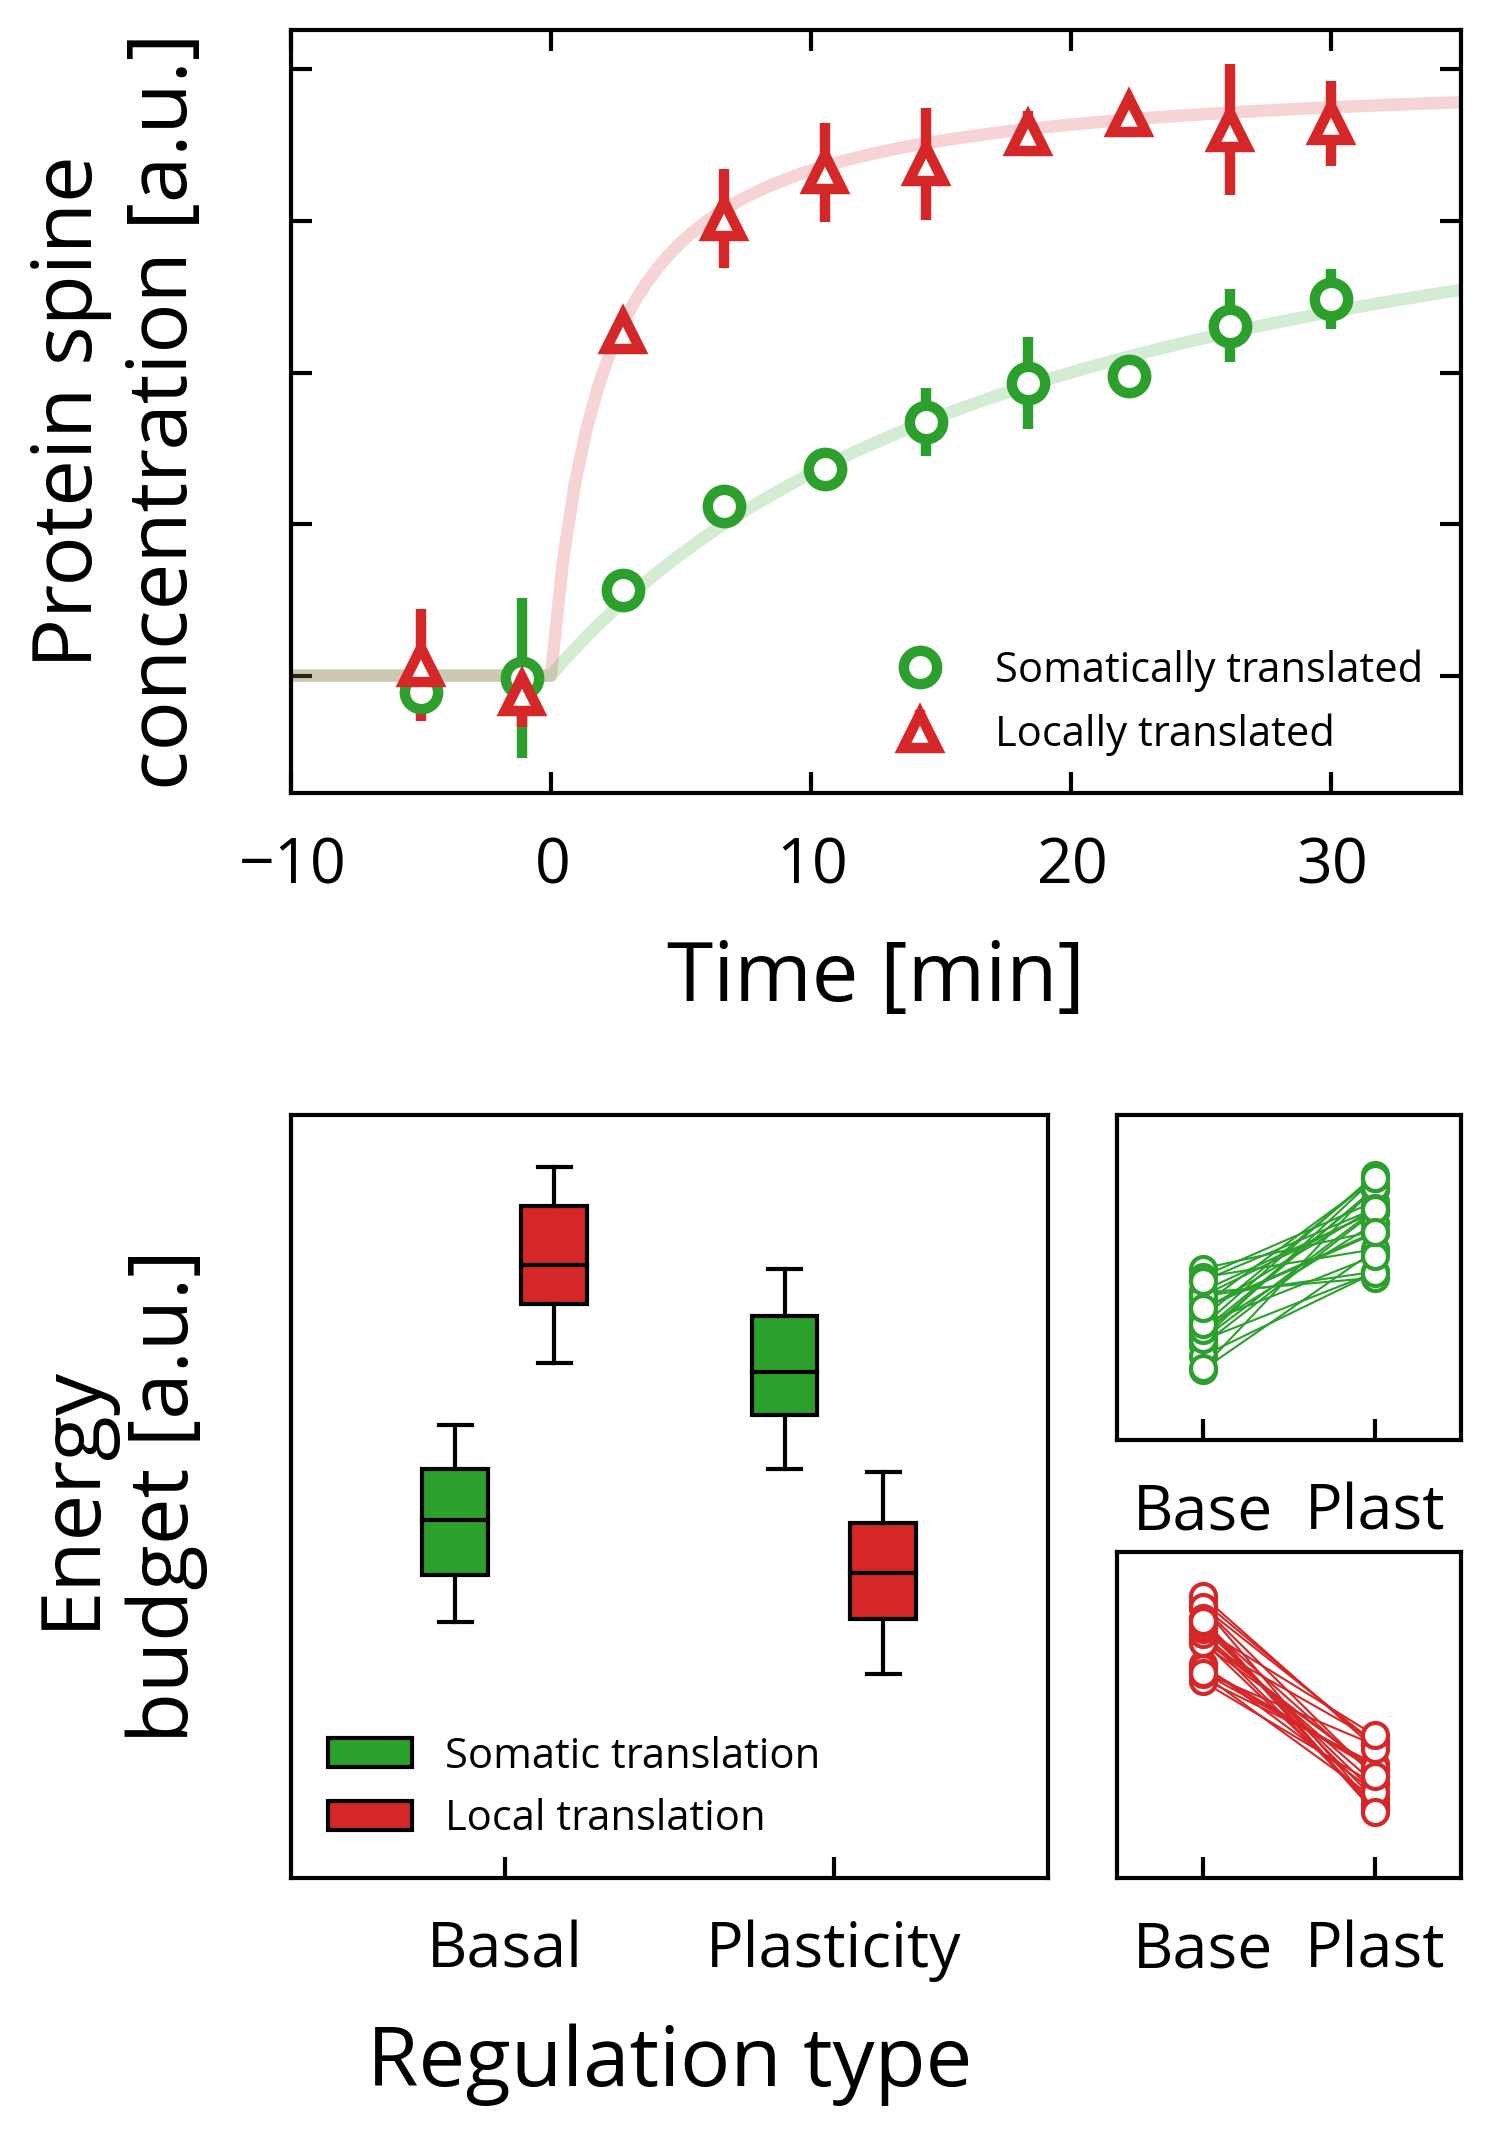

In [355]:
# fig, axs = plt.subplots(2,1, figsize=(8,8))

fig = plt.figure(figsize=(5,7), dpi=300)
gs = fig.add_gridspec(5,3, height_ratios=(1,1,0.3,1,1))

ax = fig.add_subplot(gs[:2,:])
plot_upper(ax)

ax = fig.add_subplot(gs[-2:, :-1])
plot_lower(ax)

ax = fig.add_subplot(gs[-2,-1])
plot_auxsoma(ax)

ax = fig.add_subplot(gs[-1,-1])
plot_auxdend(ax)

plt.subplots_adjust(left=0.2, bottom=0.11, right=0.98, top=0.99, 
                    hspace=0.4)

plt.savefig('graphs.png')
